#### 농구 선수의 게임 데이터를 활용한 포지션 예측을 위한 데이터 정제
- NBA농구 선수들의 게임 기록을 데이터로 사용해서 특정 농구 선수의 포지션을 예측

In [1]:
import pandas as pd
df = pd.read_csv('../Data/basketball.csv')
df.head()

,Player,Pos,3P,2P,TRB,AST,STL,BLK
0,Alex Abrines,SG,1.4,0.6,1.3,0.6,0.5,0.1
1,Steven Adams,C,0.0,4.7,7.7,1.1,1.1,1.0
2,Alexis Ajinca,C,0.0,2.3,4.5,0.3,0.5,0.6
3,Chris Andersen,C,0.0,0.8,2.6,0.4,0.4,0.6
4,Will Barton,SG,1.5,3.5,4.3,3.4,0.8,0.5


#### Column Description
- Player : 선수 이름
- Pos : 포지션(SG: Shooting Guard, C: Center)
- 3P : 한 경기당 평균 3점슛 성공 횟수
- 2P : 한 경기당 평균 2점슛 성공 횟수
- TRB : 한 경기당 평균 리바운드 성공 횟수
- AST : 한 경기당 평균 어시스트 성공 횟수
- STL : 한 경기당 평균 스틸 성공 횟수
- BLK : 한 경기당 평균 블로킹 성공 횟수

In [2]:
# Target 확인 : Pos
df.Pos.value_counts()

Pos
SG    50
C     50
Name: count, dtype: int64

#### 포지션별 내용
- C : Center는 골대, 포스트 근처에서 슛을 블로킹하고, 리바운드 하며,            
      바깥으로 쳐내며, 골대 근처에서 2점슛으로 득점을 하기도 한다.
- SG : Shooting Guard는 코트내에서 3점슛등 장거리 슛을 해서 점수를 얻는 역할

#### 데이터 시각화를 통한 EDA(탐색적 데이터 분석) 실시
: 데이터의 특징을 바탕으로 한 공간에 시각화 함으로써 머신러닝 학습에 필요한 Feature와 불필요한 Feature를 쉽게 구분

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

### 스틸, 2점슛 데이터 시각화

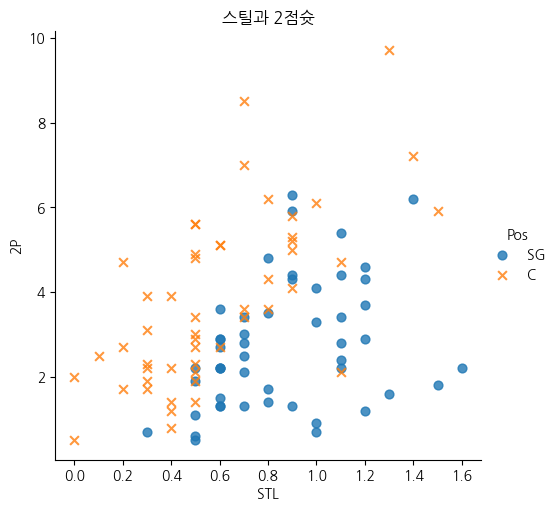

In [8]:
sns.lmplot(
    x='STL',
    y='2P',
    data=df,
    fit_reg=False, # 회귀선
    scatter_kws={'s': 40}, # 좌표상의 점의 크기
    hue='Pos',
    markers=['o', 'x']
)

plt.title('스틸과 2점슛')
plt.show()

스틸과 2점슛의 속성으로 데이터를 분포시킬 경우 슈팅가드와 센터의 경계가 너무 근접해서 분류하기에 모호하다

### 어시스트와 2점슛 데이터 시각화

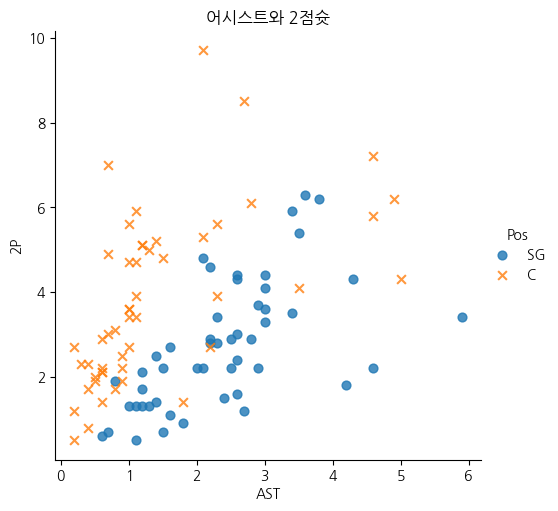

In [9]:
sns.lmplot(
    x='AST',
    y='2P',
    data=df,
    fit_reg=False,
    scatter_kws={'s': 40}, # 좌표상의 점의 크기
    hue='Pos',
    markers=['o', 'x']
)

plt.title('어시스트와 2점슛')
plt.show()

> 어시스트와 2점슛의 속성으로 데이터를 분포 시킬 경우 슈팅가드와 센터의 경계가           
너무 근접해서 분류하기에 모호하다. 단, 스틸과 2점슛의 속성보다는 나은 편이다.

### 블로킹과 3점슛의 데이터 시각화

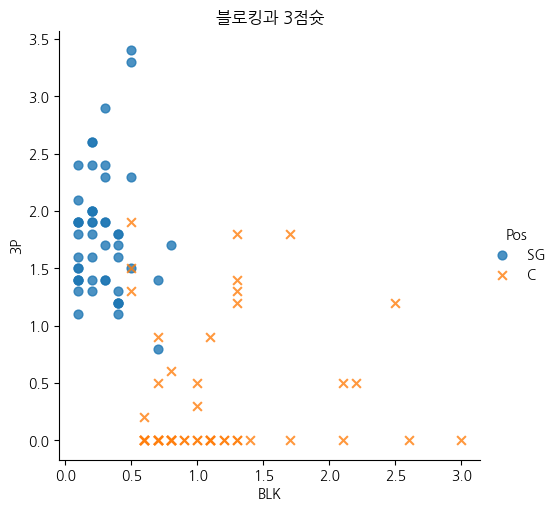

In [11]:
sns.lmplot(
    x='BLK',
    y='3P',
    data=df,
    fit_reg=False,
    scatter_kws={'s': 40}, # 좌표상의 점의 크기
    hue='Pos',
    markers=['o', 'x']
)

plt.title('블로킹과 3점슛')
plt.show()

### 리바운드와 3점슛의 데이터 시각화

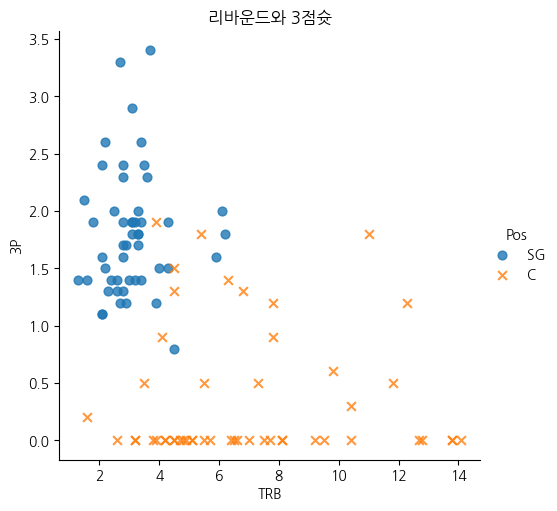

In [12]:
sns.lmplot(
    x='TRB',
    y='3P',
    data=df,
    fit_reg=False,
    scatter_kws={'s': 40}, # 좌표상의 점의 크기
    hue='Pos',
    markers=['o', 'x']
)

plt.title('리바운드와 3점슛')
plt.show()

> EDA(Explorary Data Analysis: 탐색적 데이터 분석)결과                    
분별력이 없는 Feature를 데이터에서 제거하기 위해 시각화를 해본 결과                   
2P, AST, STL은 분별력이 없는 것으로 판돤됨

In [13]:
# 분별력이 없는 Feature를 데이터에서 제거
df.drop(
    ['2P', 'AST', 'STL'],
    axis='columns',
    inplace=True
)

df.head()

,Player,Pos,3P,TRB,BLK
0,Alex Abrines,SG,1.4,1.3,0.1
1,Steven Adams,C,0.0,7.7,1.0
2,Alexis Ajinca,C,0.0,4.5,0.6
3,Chris Andersen,C,0.0,2.6,0.6
4,Will Barton,SG,1.5,4.3,0.5


----
#### 학습데이터와 테스트 데이터로 나누기

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
# 다듬어진 데이터에서 20%를 테스트 데이터로 분류
train, test = train_test_split(
    df,
    random_state=42,
    stratify=df.Pos,
    test_size=0.2
)

In [17]:
# 데이터 갯수 확인
print(train.shape)
print(test.shape)

(80, 5)
(20, 5)


In [ ]:
train.head()

In [ ]:
test.head()

In [20]:
# 데이터 저장하기
train.to_csv("../Data/basketball_train.csv", index=None)
test.to_csv("../Data/basketball_test.csv", index=None)